# 9-3 어텐션

본 노트북은 9-3절 본문 예제 [코드 9-19]~[코드 9-21]을 모아 위에서 아래로
실행해 본다. 9-2절의 미니 배치 Seq2Seq 모델에 바다나우 어텐션을 더해
노이즈가 섞인 입력에서도 잘 동작하는 날짜 변환기 모델을 만든다.

다루는 내용
- 어텐션 가중치를 계산하는 Attention 클래스 ([코드 9-19])
- 동적 콘텍스트 벡터를 만드는 디코더 ([코드 9-20])
- `encoder_output`까지 반환하는 인코더와 DateConverterAttn ([코드 9-21])
- 노이즈 데이터셋 학습, 변환 결과, 어텐션 가중치 히트맵 ([그림 9-5]~[그림 9-7])

어휘 사전/데이터셋/데이터로더, 학습 함수는 9-2절과 동일하므로 노트북에서
함께 정의한다.

In [1]:
# 참고 - 라이브러리 설치 (이미 설치된 경우 건너뛰어도 좋다)
# 9장 예제는 PyTorch 기본 패키지만으로 동작한다.
# !pip install -q matplotlib numpy torch

In [2]:
# 참고 - 공통 라이브러리 경로 설정
import sys
sys.path.append('../../')

from code_reference import common
# viz.configure()에서 save_grayscale=True로 지정하면 노트북에 표시되는 시각화 이미지를 파일로 저장함
from code_reference import visualize as viz

viz.configure(save_grayscale=False)

In [ ]:
# 참고 - 시드 고정과 학습 장치 객체 생성
SEED = 42
common.set_seed(SEED)
device = common.get_device()

CUDA를 사용합니다.


## 데이터 생성 함수 (data.ipynb 본문 복사)

9-1절의 데이터 생성 함수에 더해, 입력 날짜 문자열 앞뒤에 무작위 노이즈를
덧붙이는 `generate_noisy_datepairs`를 정의한다. 9-1절 마지막에서 다룬
정보 병목 현상을 어텐션이 어떻게 해결하는지 확인하기 위한 데이터셋이다.

In [ ]:
# 참고: 데이터 생성 함수 (9-2절과 동일)
from datetime import datetime, timedelta
import random
import string

src_formats = [
    '%d %B %Y',     # 01 February 2026
    '%d %b %Y',     # 01 Feb 2026
    '%B %d, %Y',    # February 01, 2026
    '%b %d, %Y',    # Feb 01, 2026
    '%m/%d/%Y',     # 02/01/2026
    '%Y/%m/%d',     # 2026/02/01
    '%d-%m-%Y',     # 01-02-2026
    '%Y-%m-%d',     # 2026-02-01
]

# 시작일(start_date)과 종료일(end_date) 사이의 sample_size개의 무작위 날짜 선택
def choice_random_dates(sample_size=1, start_date=None, end_date=None):
    if start_date is None:
        start_date = datetime(1900, 1, 1)
    if end_date is None:
        end_date = datetime(2050, 12, 31)
    days_between = (end_date - start_date).days
    datetime_list = []
    for _ in range(sample_size):
        days_after = random.randrange(days_between)
        datetime_list.append(start_date + timedelta(days=days_after))
    return datetime_list

# datetime 리스트를 입력 리스트와 정답 리스트로 변환하는 함수
# 입력은 src_formats에 정의된 형식으로, 정답은 'YYYY-M-D' 형식으로 변환
def generate_datepairs(date_list, src_formats=src_formats):
    if len(src_formats) == 0:
        raise ValueError('입력 문자열 템플릿이 비어 있습니다.')
    src_dates, tgt_dates = [], []
    for i, date in enumerate(date_list):
        src_format = src_formats[i % len(src_formats)]
        src_dates.append(date.strftime(src_format))
        tgt_dates.append(f'{date.year}-{date.month}-{date.day}')
    return src_dates, tgt_dates

# 노이즈 문자를 추가한 입력 문자열 생성 함수
def add_random_noise(text, max_length=40):
    # 날짜 문자열 앞뒤에 무작위 노이즈 문자를 덧붙여 최대 40자 입력을 만든다.
    noise_chars = (
        string.ascii_letters + string.digits + '!@#$%^&*()_+-=[]{}|;:,./<>?'
    )
    # 앞, 뒤에 추가할 노이즈 문자열
    prefix, suffix = '', ''
    remaining = max_length - len(text)
    if remaining > 0:
        prefix_length = random.randint(0, remaining)
        remaining -= prefix_length
        prefix = ''.join(random.choices(noise_chars, k=prefix_length))
    if remaining > 0:
        suffix_length = random.randint(0, remaining)
        suffix = ''.join(random.choices(noise_chars, k=suffix_length))
    return prefix + text + suffix

# 노이즈 문자열을 추가한 입력 날짜 문자열과 정답 날짜 문자열 리스트 생성 함수
def generate_noisy_datepairs(date_list, src_formats=src_formats):
    src_dates, tgt_dates = [], []
    for i, date in enumerate(date_list):
        src_format = src_formats[i % len(src_formats)]
        src_dates.append(add_random_noise(date.strftime(src_format)))
        tgt_dates.append(f'{date.year}-{date.month}-{date.day}')
    return src_dates, tgt_dates

# 노이즈가 섞인 데이터셋 생성
date_list = choice_random_dates(4000)
src_dates, tgt_dates = generate_noisy_datepairs(date_list)
print('노이즈 데이터셋 예시:')
for i in range(4):
    print(f'  {src_dates[i]!r} -> {tgt_dates[i]!r}')

노이즈 데이터셋 예시:
  'uKq5Mc2r0I!s%)25 September 2014Z' -> '2014-9-25'
  ']qDOx[U4120E=2_!A2hlkBq9T24 Dec 19191ZL' -> '1919-12-24'
  '495?XRmBOeFam_/June 28, 19046KR@NoY(' -> '1904-6-28'
  'zyVoO%&Jan 21, 2033TYxW?W^^NtL$6w]cx' -> '2033-1-21'


In [5]:
# 참고 - 어휘 사전, 데이터셋, 데이터로더 (9-2절과 동일)
SOS_TOKEN, EOS_TOKEN, PAD_TOKEN = '<sos>', '<eos>', '<pad>'
SOS_IDX, EOS_IDX, PAD_IDX = 0, 1, 2
special_tokens = {SOS_TOKEN: SOS_IDX, EOS_TOKEN: EOS_IDX, PAD_TOKEN: PAD_IDX}


class Vocab:
    def __init__(self, sequence_list, special_tokens):
        tokens = set()
        for sequence in sequence_list:
            tokens.update(sequence)
        self.vocab = dict(special_tokens)
        idx_start = len(special_tokens)
        for i, token in enumerate(sorted(tokens)):
            self.vocab[token] = i + idx_start
        self.itos = {idx: token for token, idx in self.vocab.items()}

    def encode(self, input_sequence):
        return [self.vocab[token] for token in input_sequence]

    def decode(self, input_ids):
        return [self.itos[idx] for idx in input_ids]

    def __len__(self):
        return len(self.vocab)


class DateDataset(Dataset):
    def __init__(self, src_dates, tgt_dates, src_vocab, tgt_vocab):
        self.samples = []
        for src_date, tgt_date in zip(src_dates, tgt_dates):
            src_ids = src_vocab.encode(src_date)
            tgt_ids = [SOS_IDX] + tgt_vocab.encode(tgt_date) + [EOS_IDX]
            self.samples.append((src_ids, tgt_ids))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]


def collate_fn(batch):
    src_batch, tgt_batch = zip(*batch)
    src_tensors = [torch.LongTensor(s) for s in src_batch]
    tgt_tensors = [torch.LongTensor(t) for t in tgt_batch]
    src_padded = pad_sequence(src_tensors, batch_first=True, padding_value=PAD_IDX)
    tgt_padded = pad_sequence(tgt_tensors, batch_first=True, padding_value=PAD_IDX)
    return src_padded, tgt_padded


src_vocab = Vocab(src_dates, special_tokens)
tgt_vocab = Vocab(tgt_dates, special_tokens)
train_set = DateDataset(src_dates[:3000], tgt_dates[:3000], src_vocab, tgt_vocab)
valid_set = DateDataset(src_dates[3000:], tgt_dates[3000:], src_vocab, tgt_vocab)
BATCH_SIZE = 32
train_loader = DataLoader(
    train_set, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn,
)
valid_loader = DataLoader(
    valid_set, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn,
)
print(f'입력 어휘 사전 크기: {len(src_vocab)}')
print(f'출력 어휘 사전 크기: {len(tgt_vocab)}')
print(f'훈련/검증 데이터셋: {len(train_set)} / {len(valid_set)}')

입력 어휘 사전 크기: 93
출력 어휘 사전 크기: 14
훈련/검증 데이터셋: 3000 / 1000


## [코드 9-19] Attention 클래스 (바다나우 어텐션)

두 개의 선형 계층으로 어텐션 가중치를 계산한다. `attn_energy`(논문의 attn)는
어텐션 에너지를, `score_projection`(논문의 v)은 어텐션 점수를 계산한다.
`<pad>` 위치는 소프트맥스 전에 음의 무한대로 마스킹해 가중치 0으로 만든다.

In [ ]:
###############################################################################
# 코드 9-19 - Attention 클래스 생성자/forward 메서드
###############################################################################
class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        # 어텐션 에너지를 계산하는 선형 계층 (바다나우 어텐션 논문의 attn에 해당)
        self.attn_energy = nn.Linear(hidden_dim * 2, hidden_dim)
        # 어텐션 점수를 계산하는 선형 계층 (바다나우 어텐션 논문의 v에 해당)
        self.score_projection = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, decoder_hidden, encoder_output, pad_mask=None):
        # decoder_hidden - 디코더 LSTM의 숨겨진 상태 (B, hidden_dim)
        # encoder_output - 인코더 LSTM의 출력 (B, src_length, hidden_dim)
        src_length = encoder_output.shape[1]
        # 현재 생성 맥락(decoder_hidden)을 입력 토큰 수만큼 복제해 입력 기억과 결합
        # (B, hidden_dim) -> (B, 1, hidden_dim) -> (B, src_length, hidden_dim)
        hidden_expanded = decoder_hidden.unsqueeze(1).repeat(1, src_length, 1)
        combined = torch.cat([hidden_expanded, encoder_output], dim=-1)
        # (B, src_length, hidden_dim + hidden_dim)

        # 1. 어텐션 에너지 계산 - attn_energy 계층 + Tanh 활성화 함수
        energy = torch.tanh(self.attn_energy(combined))
        # (B, src_length, hidden_dim * 2) -> (B, src_length, hidden_dim)

        # 2. 어텐션 점수 계산 (score_projection 계층) -> 스칼라화 (squeeze(-1))
        attention_scores = self.score_projection(energy).squeeze(-1)
        # (B, src_length, hidden_dim) -> (B, src_length, 1) -> (B, src_length)

        # 3. 어텐션 가중치 계산 - softmax() 함수 사용
        # <pad> 토큰의 어텐션 점수를 음의 무한대로 바꿈 -> softmax()의 결과는 0
        if pad_mask is not None:
            attention_scores = attention_scores.masked_fill(
                pad_mask == 0, -float('inf'),
            )
        attention_weights = torch.softmax(attention_scores, dim=1)
        return attention_weights

## [코드 9-20] 어텐션 메커니즘을 추가한 디코더 클래스

생성자에 어텐션 계층을 추가하고, `forward_step()`에서 매 토큰을 생성할 때마다
어텐션 가중치와 인코더 출력의 가중합(`torch.bmm()`)으로 동적 콘텍스트 벡터를
만들어 사용한다. 시각화를 위해 어텐션 가중치도 함께 반환한다.

In [ ]:
###############################################################################
# 코드 9-20 - 어텐션 메커니즘을 추가한 디코더 클래스
###############################################################################
# encoder_output: 인코더 LSTM 계층의 모든 시점의 숨겨진 상태(인코더 출력)
# pad_mask: <pad> 위치를 False로 기록한 마스크 텐서
class Decoder(nn.Module):
    def __init__(self, tgt_vocab_size, embed_dim, hidden_dim, num_layers):
        super().__init__()
        self.decoder_embedding = nn.Embedding(tgt_vocab_size, embed_dim)
        self.attention = Attention(hidden_dim)      # 어텐션 계층 추가
        # 동적 콘텍스트 벡터의 길이: hidden_dim (이전 콘텍스트 벡터와 동일)
        self.decoder_lstm = nn.LSTM(
            embed_dim + hidden_dim, hidden_dim,
            num_layers=num_layers, batch_first=True,
        )
        self.fc = nn.Linear(hidden_dim, tgt_vocab_size)

    # 고정 콘텍스트 벡터 대신 어텐션 메커니즘의 동적 콘텍스트 벡터를 사용해 생성
    def forward_step(self, token, hidden, cell, encoder_output, pad_mask):
        embedded = self.decoder_embedding(token)
        # 인코더 LSTM의 output(encoder_output)을 사용해 어텐션 가중치 계산
        attention_weights = self.attention(hidden[-1], encoder_output, pad_mask)
        # 4. 어텐션 가중치를 사용한 가중합으로 동적 콘텍스트 벡터 계산
        # 배치 행렬곱 함수 torch.bmm()은 추가 설명 참조
        context = torch.bmm(attention_weights.unsqueeze(1), encoder_output)
        lstm_input = torch.cat([embedded, context], dim=-1)
        output, (hidden, cell) = self.decoder_lstm(lstm_input, (hidden, cell))
        logits = self.fc(output.squeeze(1))
        # 어텐션 가중치도 함께 반환 (시각화용)
        return logits, hidden, cell, attention_weights

    # 메서드 파라미터: context 삭제, encoder_output, pad_mask 추가
    def forward(self, tgt, hidden, cell, encoder_output, pad_mask=None,
                forcing_ratio=0.5):
        _, target_length = tgt.shape
        all_logits = []
        token = tgt[:, 0:1]
        for i in range(target_length):
            # context 대신 encoder_output과 pad_mask 인자 추가
            logits, hidden, cell, _ = self.forward_step(
                token, hidden, cell, encoder_output, pad_mask,
            )
            all_logits.append(logits.unsqueeze(1))
            if i + 1 < target_length:
                use_teacher_forcing = random.random() < forcing_ratio
                if use_teacher_forcing:
                    token = tgt[:, i + 1:i + 2]
                else:
                    token = logits.argmax(dim=-1, keepdim=True)  # (B, 1)
        return torch.cat(all_logits, dim=1)

## [코드 9-21] 어텐션을 적용한 인코더와 DateConverterAttn 클래스

인코더는 어텐션 계산에 필요한 LSTM 출력(`encoder_output`)을 언패킹해 함께
반환한다. `DateConverterAttn`은 `<pad>` 위치를 False로 기록한 패딩 마스크를
만들어 `encoder_output`과 함께 디코더로 전달한다.

In [ ]:
###############################################################################
# 코드 9-21 - 어텐션 메커니즘을 적용한 인코더와 DateConverterAttn 클래스
###############################################################################
class Encoder(nn.Module):
    def __init__(self, src_vocab_size, embed_dim, hidden_dim, num_layers):
        super().__init__()
        self.encoder_embedding = nn.Embedding(src_vocab_size, embed_dim)
        self.encoder_lstm = nn.LSTM(
            embed_dim, hidden_dim,
            num_layers=num_layers, batch_first=True,
        )

    def forward(self, src, src_lengths):
        embedded = self.encoder_embedding(src)
        packed_embedding = pack_padded_sequence(
            embedded, src_lengths.cpu(),
            batch_first=True, enforce_sorted=False,
        )
        packed_output, (hidden, cell) = self.encoder_lstm(packed_embedding)
        # 어텐션 메커니즘에 필요하므로 패킹된 LSTM 출력을 언패킹해서 함께 반환한다.
        encoder_output, _ = pad_packed_sequence(packed_output, batch_first=True)
        return encoder_output, hidden, cell


# 어텐션 메커니즘을 적용한 Seq2Seq 날짜 변환기 클래스
class DateConverterAttn(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, tgt, src_lengths):
        # encoder_output까지 반환값에 추가
        encoder_output, hidden, cell = self.encoder(src, src_lengths)
        # <pad> 토큰 위치를 False로 기록한 패딩 마스크 생성
        pad_mask = (src != PAD_IDX)              # (B, src_length)
        tgt_input = tgt[:, :-1]
        # 콘텍스트 벡터 대신 encoder_output, pad_mask를 디코더에 전달
        logits = self.decoder(tgt_input, hidden, cell, encoder_output, pad_mask)
        return logits

## 학습 함수와 학습 실행

어텐션은 클래스 내부에만 적용되어 9-2절의 학습 함수를 그대로 사용한다.
배치 크기 32, 노이즈 데이터셋 환경에서 DateConverterAttn 모델을 학습한다.

In [9]:
# 참고 - 학습 함수 (9-2절 패턴과 동일, ignore_index=PAD_IDX)
def train_epoch(model, train_loader, criterion, optimizer, device=None):
    if device is None:
        device = torch.device('cpu')
    model.train()
    total_loss, token_count = 0.0, 0
    for src, tgt in train_loader:
        src, tgt = src.to(device), tgt.to(device)
        src_lengths = (src != PAD_IDX).sum(dim=1)
        optimizer.zero_grad()
        logits = model(src, tgt, src_lengths)
        labels = tgt[:, 1:]
        loss = criterion(
            logits.reshape(-1, logits.size(-1)),
            labels.reshape(-1),
        )
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        n_tokens = (labels != PAD_IDX).sum().item()
        total_loss += loss.item() * n_tokens
        token_count += n_tokens
    return total_loss / token_count


@torch.no_grad()
def validation_epoch(model, valid_loader, criterion, device=None):
    if device is None:
        device = torch.device('cpu')
    model.eval()
    total_loss, token_count = 0.0, 0
    correct_size, sample_size = 0, 0
    for src, tgt in valid_loader:
        src, tgt = src.to(device), tgt.to(device)
        src_lengths = (src != PAD_IDX).sum(dim=1)
        logits = model(src, tgt, src_lengths)
        labels = tgt[:, 1:]
        loss = criterion(
            logits.reshape(-1, logits.size(-1)),
            labels.reshape(-1),
        )
        n_tokens = (labels != PAD_IDX).sum().item()
        total_loss += loss.item() * n_tokens
        token_count += n_tokens
        preds = logits.argmax(dim=-1)
        mask = labels != PAD_IDX
        sample_correct = ((preds == labels) | ~mask).all(dim=1)
        correct_size += sample_correct.sum().item()
        sample_size += src.size(0)
    return total_loss / token_count, correct_size / sample_size * 100.0


def train_loop(model, train_loader, valid_loader, criterion, optimizer,
               epochs, patience, device=None):
    """조기 종료 + 최적 모델 복원 학습 루프.

    학습 로그·전체 학습 시간·최적 에포크·학습 곡선은 공통코드컨벤션
    §7.6/§7.7에 따라 common.EpochLogger로 통일한다(검증 손실·정확도가
    있으므로 훈련 손실·검증 손실·정확도(%) 3열).
    """
    if device is None:
        device = torch.device('cpu')
    model.to(device)
    log = common.EpochLogger(epochs, target_rows=epochs)        # 훈련 손실 · 검증 손실 · 정확도(%)
    best_valid_loss = float('inf')
    best_state, best_epoch, counter = None, 0, 0
    stopped = False
    for epoch in range(1, epochs + 1):
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        valid_loss, valid_acc = validation_epoch(model, valid_loader, criterion, device)
        # valid_acc는 이미 백분율 수(0~100)
        log.row(epoch, train_loss, valid_loss, valid_acc)
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            best_state = copy.deepcopy(model.state_dict())
            best_epoch, counter = epoch, 0
        else:
            counter += 1
            if counter >= patience:
                stopped = True
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    log.summary(stopped='조기 종료' if stopped else None)
    return {'log': log, 'best_epoch': best_epoch}


criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

In [10]:
# 참고 - 어텐션 모델 학습 (노이즈 데이터셋)
EMBED_DIM = 32
HIDDEN_DIM = 32
NUM_LAYERS = 1

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

encoder = Encoder(len(src_vocab), EMBED_DIM, HIDDEN_DIM, NUM_LAYERS)
decoder = Decoder(len(tgt_vocab), EMBED_DIM, HIDDEN_DIM, NUM_LAYERS)
model_attn = DateConverterAttn(encoder, decoder).to(device)

LR = 1e-3
optimizer = optim.Adam(model_attn.parameters(), lr=LR)

EPOCHS = 120
PATIENCE = 5
history_attn = train_loop(
    model_attn, train_loader, valid_loader, criterion, optimizer,
    epochs=EPOCHS, patience=PATIENCE, device=device,
)

  epoch    훈련 손실    검증 손실    정확도(%)     시간
  1/120       2.1985       1.8290        0.00%     0:05
  2/120       1.6782       1.5559        0.00%     0:08
  3/120       1.4878       1.4321        0.00%     0:12
  4/120       1.3564       1.3166        0.00%     0:16
  5/120       1.2699       1.2254        0.00%     0:19
  6/120       1.2045       1.1716        0.00%     0:23
  7/120       1.1431       1.1146        0.00%     0:26
  8/120       1.0837       1.0679        0.00%     0:30
  9/120       1.0376       1.0259        0.00%     0:33
 10/120       0.9955       1.0001        0.00%     0:36
 11/120       0.9648       0.9645        0.00%     0:40
 12/120       0.9302       0.9477        0.10%     0:44
 13/120       0.9047       0.9140        0.00%     0:47
 14/120       0.8768       0.8841        0.10%     0:51
 15/120       0.8407       0.8636        0.20%     0:54
 16/120       0.8130       0.8230        0.50%     0:58
 17/120       0.7794       0.8016        0.60%     1:01
 18/1

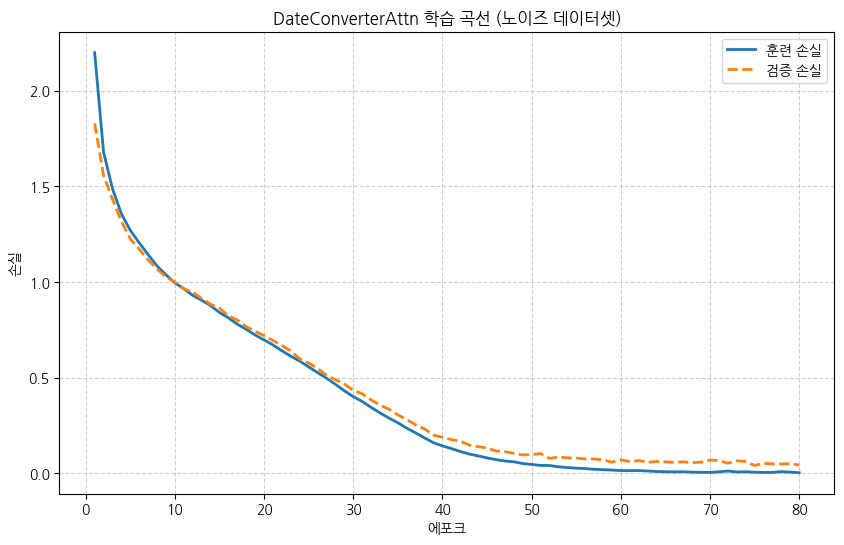

In [11]:
# 참고 - 어텐션 모델 학습 곡선 (EpochLogger 내장 plot, §7.7)
history_attn['log'].plot(title='DateConverterAttn 학습 곡선 (노이즈 데이터셋)')

In [12]:
# 참고 - 모델 파라미터 수
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

param_count = count_parameters(model_attn)
print(f'어텐션 모델 파라미터 수: {param_count:,}개')

어텐션 모델 파라미터 수: 26,990개


## 어텐션 모델로 변환 결과 확인

예측 함수는 한 샘플만 예측해 패딩이 없더라도 디코더 시그니처에 맞춰 패딩
마스크를 만들어 `encoder_output`과 함께 전달해야 한다. 노이즈를 섞은 입력과
섞지 않은 입력 모두 정답으로 변환되는지 확인한다.

In [13]:
# @TODO - 어텐션 반환 예측 함수와 예측만 하는 함수 분리
# 참고 - 어텐션 모델의 예측 함수 (어텐션 가중치도 함께 수집)
@torch.no_grad()
def predict_with_attention(model, src_text, src_vocab, tgt_vocab, device=None, max_length=12):
    if device is None: device = torch.device('cpu')
    model.eval()

    src_ids = src_vocab.encode(src_text)
    src = torch.LongTensor(src_ids).unsqueeze(0).to(device)
    # 인코더 - 동적 컨텍스트 벡터를 만들기 위한 숨겨진 상태(encoder_output)뿐 아니라 
    #          디코더 LSTM 초기화를 위한 마지막 숨겨진 상태(hidden)와 셀 상태(cell)도 함께 반환
    src_lengths = torch.LongTensor([len(src_ids)])
    encoder_output, hidden, cell = model.encoder(src, src_lengths)
    # 샘플 하나만 예측해도 패딩 마스크 필요(디코더 입력 인자)
    pad_mask = (src != PAD_IDX)
    tgt_token = torch.tensor([[SOS_IDX]]).to(device)
    result_ids = []
    attention_list = []
    # 최대 max_length 토큰까지 자기 회귀 방식으로 반복 생성
    for _ in range(max_length):
        logits, hidden, cell, attn = model.decoder.forward_step(
            tgt_token, hidden, cell, encoder_output, pad_mask,
        )
        prediction = logits.argmax(dim=-1, keepdim=True)
        attention_list.append(attn[0].cpu().numpy())
        if prediction.item() == EOS_IDX:
            break
        result_ids.append(prediction.item())
        tgt_token = prediction
    text = ''.join(tgt_vocab.decode(result_ids))
    # 출력 토큰 수만큼만 어텐션 가중치 유지
    attention_weights = np.stack(attention_list[:len(text)])
    return text, attention_weights


def predict(model, src_text, src_vocab, tgt_vocab, device=None, max_length=12):
    text, _ = predict_with_attention(model, src_text, src_vocab, tgt_vocab, device, max_length)
    return text


# 임의 날짜 하나의 노이즈 / 비노이즈 변환 결과
random.seed(SEED)
test_date = choice_random_dates(1) * 8
clean_src, clean_tgt = generate_datepairs(test_date)
noisy_src, noisy_tgt = generate_noisy_datepairs(test_date)
print(f'정답 날짜 문자열: {clean_tgt[0]}\n')
print('노이즈 없는 날짜 문자열 변환:')
print('  입력 날짜 문자열                         => 예측 날짜 문자열 (정답 여부)')
for src_text, tgt_text in zip(clean_src, clean_tgt):
    pred = predict(model_attn, src_text, src_vocab, tgt_vocab, device)
    mark = '정답' if pred == tgt_text else '오답'
    print(f'  {src_text:<40s} => {pred} ({mark})')

print('\n노이즈를 추가한 날짜 문자열 변환:')
print('  입력 날짜 문자열                         => 예측 날짜 문자열 (정답 여부)')
for src_text, tgt_text in zip(noisy_src, noisy_tgt):
    pred = predict(model_attn, src_text, src_vocab, tgt_vocab, device)
    mark = '정답' if pred == tgt_text else '오답'
    print(f'  {src_text:<40s} => {pred} ({mark})')

정답 날짜 문자열: 2014-9-25

노이즈 없는 날짜 문자열 변환:
  입력 날짜 문자열                         => 예측 날짜 문자열 (정답 여부)
  25 September 2014                        => 2014-9-25 (정답)
  25 Sep 2014                              => 2014-9-25 (정답)
  September 25, 2014                       => 2014-9-25 (정답)
  Sep 25, 2014                             => 2014-9-25 (정답)
  09/25/2014                               => 2014-9-25 (정답)
  2014/09/25                               => 2014-9-25 (정답)
  25-09-2014                               => 2014-9-25 (정답)
  2014-09-25                               => 2014-9-25 (정답)

노이즈를 추가한 날짜 문자열 변환:
  입력 날짜 문자열                         => 예측 날짜 문자열 (정답 여부)
  cyt25 September 20148}h                  => 2014-9-25 (정답)
  ciu1X@!LNy]^o25 Sep 2014En/Dii=1)#V<H    => 2014-9-25 (정답)
  A3{Grg6&>[]HO-oF7September 25, 2014,52p# => 2014-9-25 (정답)
  Py:9tSep 25, 2014=*ucCxs,]C              => 2014-9-25 (정답)
  S{5mm%V%MZG?mR^[no8109/25/2014H?V<[b     => 2014-9-25 (정답)
  k{%&EAoa##<^Tj3-TrHo.:;2014/09

In [14]:
# 추후 삭제
import importlib.util
importlib.reload(viz)
viz.configure(save_grayscale=False)

## [그림 9-5]~[그림 9-7] 어텐션 가중치 시각화

어텐션 가중치 히트맵으로 모델이 각 출력 토큰을 생성할 때 입력의 어느 위치에
집중했는지를 확인한다. 가로축이 입력 토큰, 세로축이 출력 토큰이며 색이 진할수록
어텐션 가중치가 높다.

'Sep 18, 1938' → '1938-9-18'


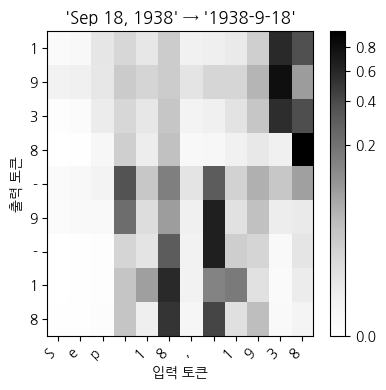

In [20]:
# 참고 - 어텐션 가중치 히트맵 ([그림 9-5] - Sep 18, 1938)
src_text = 'Sep 18, 1938'
pred, attention_weights = predict_with_attention(
    model_attn, src_text, src_vocab, tgt_vocab, device,
)
print(f'{src_text!r} → {pred!r}')
viz.plot_attention(
    attention_weights,
    source_tokens=list(src_text),
    target_tokens=list(pred),
    title=f'{src_text!r} → {pred!r}',
    figsize=(4, 4),
    gamma=0.3
)

'18 Sep 1938' → '1938-9-18'


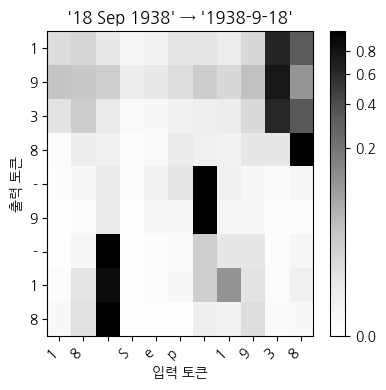

In [21]:
# 참고 - 어텐션 가중치 히트맵 ([그림 9-5] - 18 Sep 1938)
src_text = '18 Sep 1938'
pred, attention_weights = predict_with_attention(
    model_attn, src_text, src_vocab, tgt_vocab, device,
)
print(f'{src_text!r} → {pred!r}')
viz.plot_attention(
    attention_weights,
    source_tokens=list(src_text),
    target_tokens=list(pred),
    title=f'{src_text!r} → {pred!r}',
    figsize=(4, 4),
    gamma=0.3
)

'18 September 1938' → '1938-9-18'


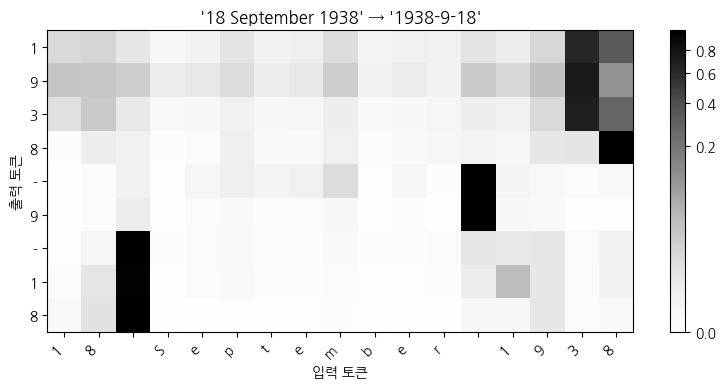

In [ ]:
# 참고: 긴 날짜 문자열 변환의 어텐션 가중치 히트맵 
src_text = '18 September 1938'
pred, attention_weights = predict_with_attention(
    model_attn, src_text, src_vocab, tgt_vocab, device,
)
print(f'{src_text!r} → {pred!r}')
viz.plot_attention(
    attention_weights,
    source_tokens=list(src_text),
    target_tokens=list(pred),
    title=f'{src_text!r} → {pred!r}',
    figsize=(8, 4),
    gamma=0.3
)

'0q?-U:k!U]}T1991/07/15FR?OdR{z=W@@b' → '1991-7-15'


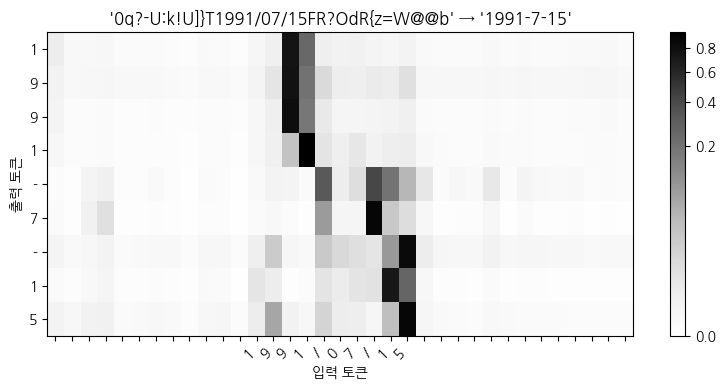

In [26]:
# 참고 - 노이즈 입력의 어텐션 가중치 ([그림 9-7])
src_text = '0q?-U:k!U]}T1991/07/15FR?OdR{z=W@@b'
date_str = '1991/07/15'

start = src_text.index(date_str)
src_labels = [''] * len(src_text)
src_labels[start:start + len(date_str)] = list(date_str)
pred, attention_weights = predict_with_attention(
    model_attn, src_text, src_vocab, tgt_vocab, device,
)
print(f'{src_text!r} → {pred!r}')
viz.plot_attention(
    attention_weights,
    source_tokens=src_labels,
    target_tokens=list(pred),
    title=f'{src_text!r} → {pred!r}',
    figsize=(8, 4),
    gamma=0.3
)

## 어텐션 가중치 해석

- 어텐션 메커니즘은 매 출력 토큰을 생성할 때 입력의 어느 부분에 집중할지를
  동적으로 계산해 동적 콘텍스트 벡터를 만든다. 덕분에 노이즈가 섞인 입력에서도
  의미 있는 토큰을 골라내 정확도를 크게 끌어올린다.
- 히트맵을 보면 입력 형식과 무관하게 연/월/일을 생성할 때 입력의 해당 위치에
  가중치가 집중되며, 노이즈 위치의 가중치는 매우 낮게 유지된다.
- 어텐션 가중치 시각화는 모델이 어떤 근거로 출력을 만들었는지를 눈으로 확인할
  수 있게 해 주어 모델의 해석 가능성을 높인다.